In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

In [12]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [13]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [14]:
model = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
    layers.Dense(3, activation="sigmoid", name="layer3"),
    layers.Dense(3, activation="sigmoid", name="layer4"),
  ]
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
y = model(X)
print(y[149])

tf.Tensor([0.352263   0.46607497 0.4256117 ], shape=(3,), dtype=float32)


In [16]:
optimizer=tf.keras.optimizers.SGD(learning_rate=0.03)
loss=tf.keras.losses.MeanSquaredError()

model.compile(optimizer, loss)
history = model.fit(X, Y, epochs=500)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2309  
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2306 
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2304 
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2302 
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2300 
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2298 
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2296 
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2294 
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2292 
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2291
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2289 
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2287 
Epoch 13/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2286 
Epoch 14/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2284 
Epoch 15/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2282 
Epoch 16/500
5/5 ━

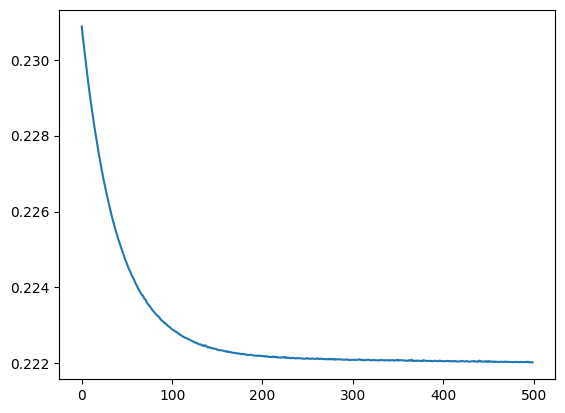

In [17]:
plt.plot(history.history['loss'])
plt.show()

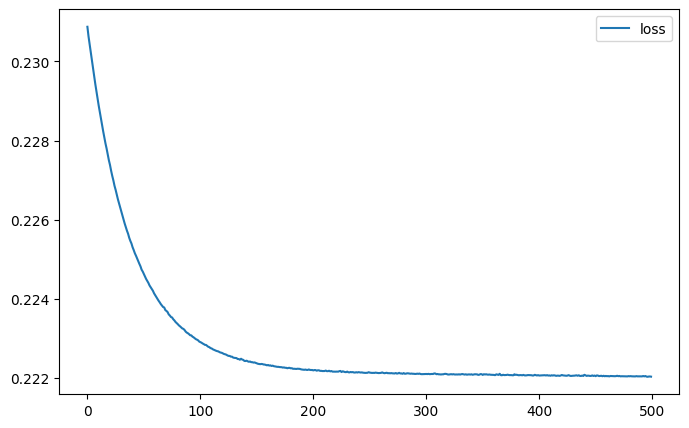

In [18]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

In [19]:
model.predict(np.array([[3,3,1,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


array([[0.33436936, 0.33166143, 0.3311125 ]], dtype=float32)